In [ ]:
from pathlib import Path
from blimpy import Waterfall

directory = Path("/datag/public/A_Sign_in_Space_raw_h5")

patterns = [
    "*.rawspec.0000.h5",
    "*.rawspec.0001.h5",
    "*.rawspec.0002.h5",
]

for pattern in patterns:
    matches = sorted(directory.glob(pattern))
    if not matches:
        continue

    f = matches[0]

    print("=" * 80)
    print(f"Inspecting: {f.name}")

    # Header only
    wf = Waterfall(str(f), load_data=False)

    print(f"foff   : {wf.header['foff']}")
    print(f"tsamp  : {wf.header['tsamp']}")
    print(f"nchans : {wf.header['nchans']}")
    print(f"shape  : {wf.container.selection_shape}")

    # Read only the first 10 frequency channels
    fch1 = wf.header["fch1"]
    foff = wf.header["foff"]

    wf_small = Waterfall(
        str(f),
        f_start=fch1 + 10 * foff,
        f_stop=fch1,
    )

    print("\nTiny data sample:")
    print(wf_small.data)
    print()

In [ ]:
from pathlib import Path

directory = Path("/datag/public/A_Sign_in_Space_raw_h5")

midres_files = sorted(directory.glob("*.rawspec.0002.h5"))

print(f"Found {len(midres_files)} mid-resolution files:\n")

for f in midres_files:
    print(f.name)

In [2]:
from blimpy import Waterfall

wf = Waterfall(
    "/datag/public/A_Sign_in_Space_raw_h5/blc33_guppi_60067_75323_PSR_B0355+54_0012.rawspec.0002.h5",
    load_data=False,
)

print(wf.header["fch1"])
print(wf.header["foff"])
print(wf.header["nchans"])

f_stop = wf.header["fch1"]
f_start = f_stop + wf.header["foff"] * wf.header["nchans"]

print(f_start, f_stop)

8438.96484375
-0.00286102294921875
65536
8251.46484375 8438.96484375


     Top_Hit  Drift_Rate       SNR  Uncorrected_Frequency  \
745      746 -143.769888  3.818304            8407.254619   
348      349  115.015910  3.766401            8407.247605   
315      316  162.939206  3.748207            8407.203285   
767      768   86.261933  3.695627            8407.437848   
778      779 -182.108525  3.685302            8407.223127   
572      573 -306.709095  3.682420            8407.258823   
653      654 -124.600570  3.681518            8407.246046   
711      712  469.648301  3.679463            8407.240643   
254      255  220.447162  3.668661            8407.234787   
639      640 -162.939206  3.644953            8407.223137   
225      226  230.031821  3.642296            8407.239084   
381      382 -450.478983  3.633826            8407.245871   
235      236  239.616480  3.606960            8407.209048   
471      472  412.140346  3.601446            8407.232029   
896      897   57.507955  3.591246            8407.444985   
879      880   67.092614

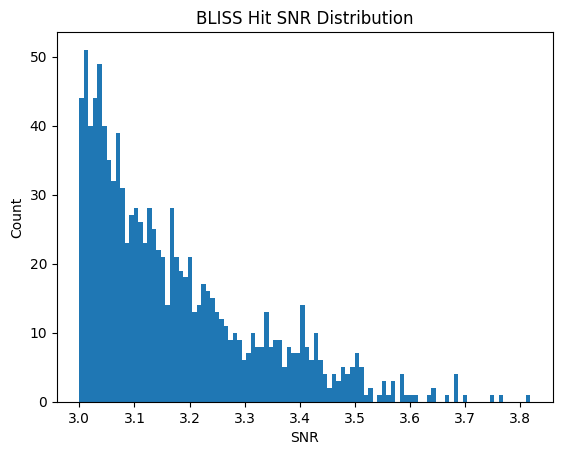

Number of hits: 1106
Maximum SNR: 3.818304
Number above 5 sigma: 0
Number above 10 sigma: 0


In [7]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(
    "/home/wlll2x/turboSETI/PSR_B0355_midres.dat",
    sep=r"\s+",
    comment="#",
    header=None
)

# Remove the unexplained extra column
df = df.iloc[:, :11]

df.columns = [
    "Top_Hit",
    "Drift_Rate",
    "SNR",
    "Uncorrected_Frequency",
    "Corrected_Frequency",
    "Index",
    "freq_start",
    "freq_end",
    "SEFD_freq",
    "Coarse_Channel_Number",
    "Full_number_of_hits"
]

# Strongest candidates
print(df.sort_values("SNR", ascending=False).head(20))

# Summary statistics
print(df["SNR"].describe())

# SNR distribution
plt.hist(df["SNR"], bins=100)
plt.xlabel("SNR")
plt.ylabel("Count")
plt.title("BLISS Hit SNR Distribution")
plt.show()

print("Number of hits:", len(df))
print("Maximum SNR:", df["SNR"].max())
print("Number above 5 sigma:", (df["SNR"] > 5).sum())
print("Number above 10 sigma:", (df["SNR"] > 10).sum())

In [3]:
import glob

files = sorted(glob.glob("/datag/public/A_Sign_in_Space_raw_h5/*_0012*.dat"))

print(f"Found {len(files)} files")
print(files[:5])

Found 0 files
[]


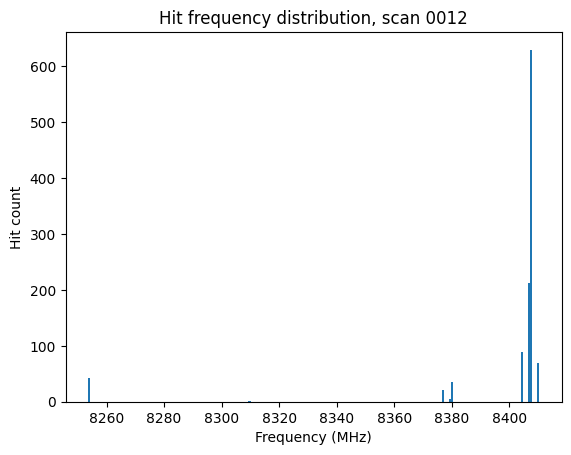

In [5]:
import glob
import pandas as pd
import matplotlib.pyplot as plt

files = sorted(
    glob.glob("/mnt_home/wlll2x/midres_narrow/results/*0012*.dat")
)



freqs = []
for f in files:
    df = pd.read_csv(f, sep=r"\s+", comment="#", header=None)
    freqs.extend(df[4])  # frequency column index depends on your .dat format — check header

plt.hist(freqs, bins=200)
plt.xlabel("Frequency (MHz)")
plt.ylabel("Hit count")
plt.title("Hit frequency distribution, scan 0012")
plt.savefig("hit_histogram.png")

In [1]:
from blimpy import Waterfall
import numpy as np

f="/datag/public/A_Sign_in_Space_raw_h5/blc33_guppi_60067_72149_EXOMARS16TGO_DIAG_0010.rawspec.0002.h5"

wf = Waterfall(f)

data = wf.data[:,0,:]

times = []
freqs = []

for t in range(data.shape[0]):
    idx = np.argmax(data[t])
    freq = wf.header["fch1"] + idx*wf.header["foff"]

    times.append(t*wf.header["tsamp"])
    freqs.append(freq)

times = np.array(times)
freqs = np.array(freqs)

coef = np.polyfit(times, freqs,1)

drift_hz = coef[0]*1e6

print()
print("Estimated drift:")
print(f"{drift_hz:.2f} Hz/s")

/home/wlll2x/.conda/envs/willvenv/lib/python3.10/site-packages/blimpy/__init__.py:21: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound



Estimated drift:
-51.59 Hz/s


In [2]:
from blimpy import Waterfall
import matplotlib.pyplot as plt
import numpy as np

f="/datag/public/A_Sign_in_Space_raw_h5/blc33_guppi_60067_72149_EXOMARS16TGO_DIAG_0010.rawspec.0002.h5"

wf = Waterfall(f)

data = wf.data[:,0,:]

times=[]
freqs=[]

for t in range(data.shape[0]):
    idx=np.argmax(data[t])
    freq=wf.header["fch1"]+idx*wf.header["foff"]

    times.append(t*wf.header["tsamp"])
    freqs.append(freq)

plt.figure(figsize=(8,5))
plt.plot(times,freqs)

plt.xlabel("Time (s)")
plt.ylabel("Frequency (MHz)")
plt.title("Brightest channel vs Time")

plt.tight_layout()
plt.savefig("orbiter_drift.png",dpi=200)

In [3]:
from blimpy import Waterfall
import matplotlib.pyplot as plt

f="/datag/public/A_Sign_in_Space_raw_h5/blc33_guppi_60067_72149_EXOMARS16TGO_DIAG_0010.rawspec.0002.h5"

wf=Waterfall(f)

data=wf.data[:,0,9900:10150]

plt.figure(figsize=(8,6))

plt.imshow(
    data,
    aspect="auto",
    origin="lower",
    interpolation="nearest"
)

plt.colorbar(label="Power")

plt.xlabel("Fine channel")
plt.ylabel("Time")

plt.tight_layout()

plt.savefig("orbiter_waterfall.png",dpi=200)

/tmp/ipykernel_3182039/2657809909.py:4: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(


      id      drift           snr        ufreq        cfreq  index  \
45    46 -58.443253  26333.203125  8410.181491  8410.181491    817   
26    27 -56.057814  23811.267578  8410.181492  8410.181492    818   
88    89 -53.672375  22285.388672  8410.184355  8410.184355    819   
353  354 -51.286937  21013.589844  8410.184356  8410.184356    820   
189  190 -48.901498  19273.248047  8410.187218  8410.187218    821   
38    39 -47.708778  18855.714844  8410.185788  8410.185788    822   
347  348 -45.323339  18725.742188  8410.188651  8410.188651    823   
361  362 -41.745181  17803.273438  8410.190083  8410.190083    825   
152  153 -44.130620  16993.306641  8410.187221  8410.187221    824   
148  149 -38.167023  16690.974609  8410.191515  8410.191515    827   
310  311 -36.974303  16152.382812  8410.192947  8410.192947    828   
64    65 -40.552461  16025.880859  8410.191514  8410.191514    826   
137  138 -33.396145  15720.449219  8410.194379  8410.194379    830   
141  142 -32.203425 

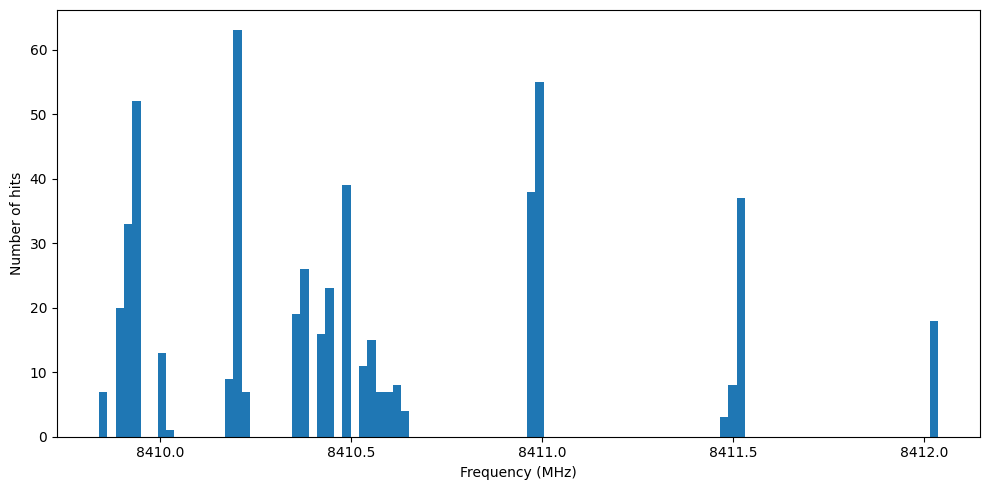

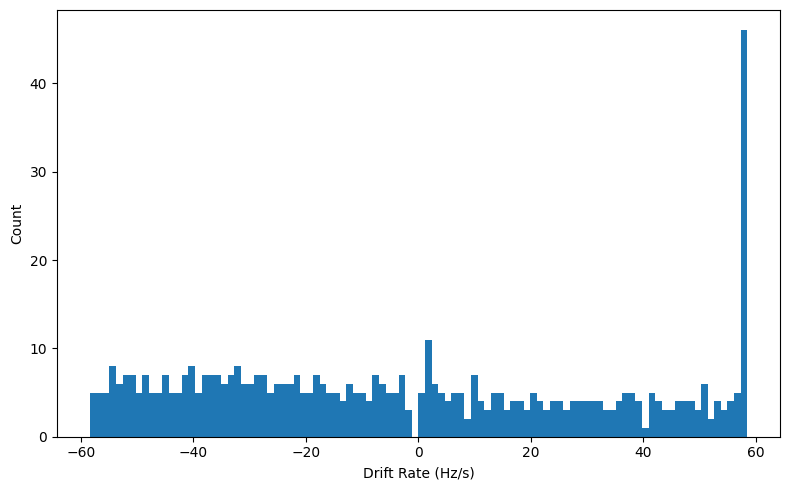

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(
    "exomars_cc9.dat",
    comment="#",
    delim_whitespace=True,
    header=None,
    names=[
        "id","drift","snr",
        "ufreq","cfreq","index",
        "start","end",
        "a","b","coarse","nhits"
    ]
)

plt.figure(figsize=(10,5))
plt.hist(df["ufreq"], bins=100)
plt.xlabel("Frequency (MHz)")
plt.ylabel("Number of hits")
plt.tight_layout()
plt.savefig("frequency_histogram.png", dpi=200)


plt.figure(figsize=(8,5))
plt.hist(df["drift"], bins=100)
plt.xlabel("Drift Rate (Hz/s)")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("drift_histogram.png", dpi=200)

print(
    df.sort_values("snr", ascending=False)
      .head(30)
)